Read code taken from Kaggle

In [1]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        



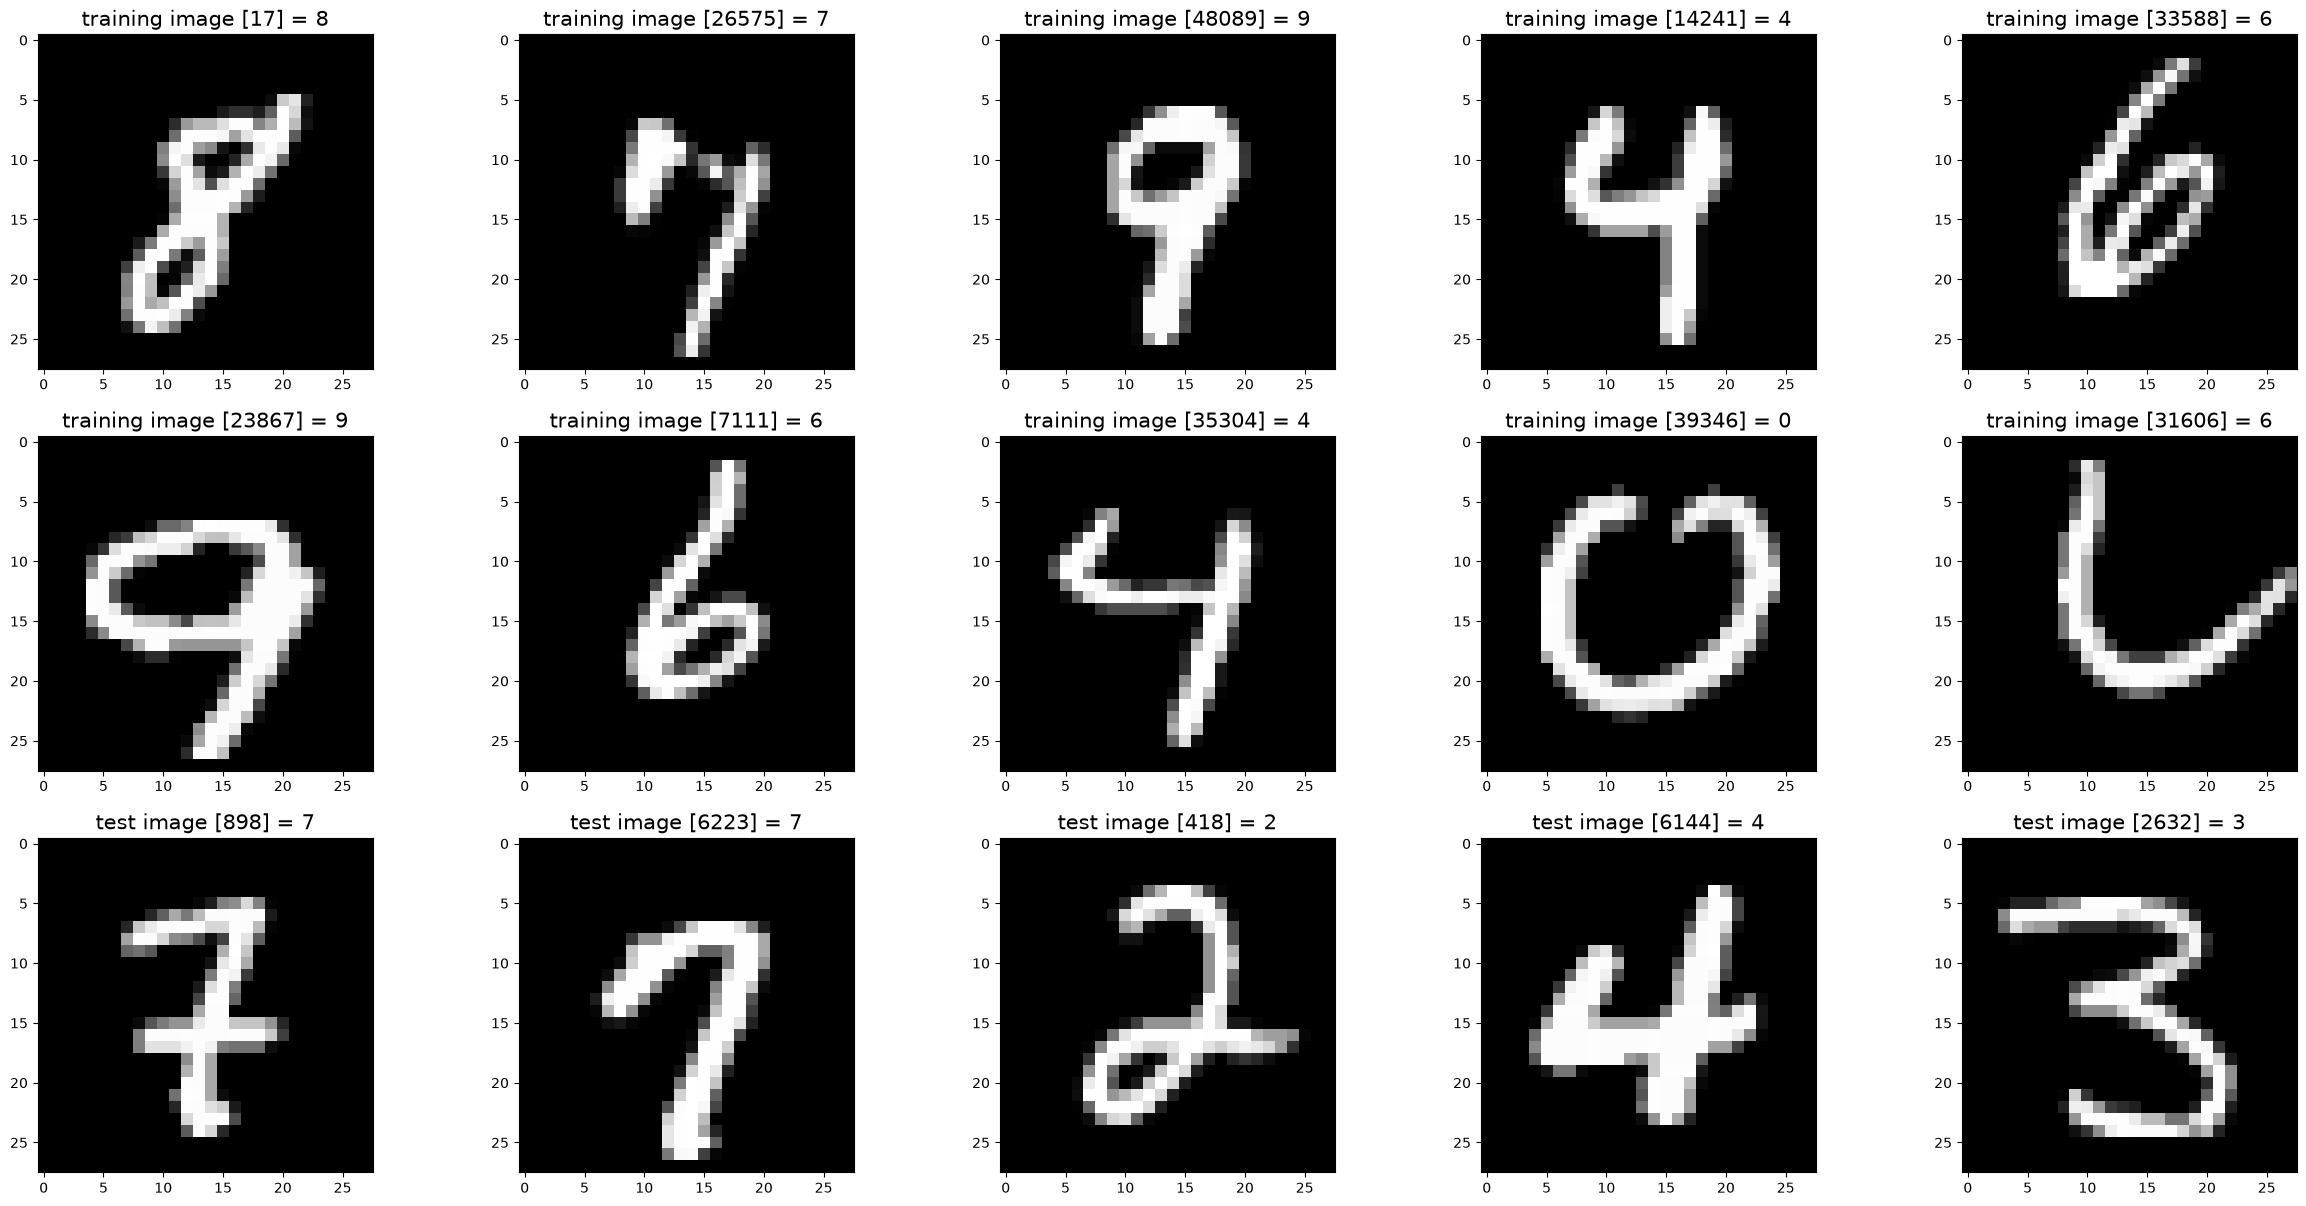

In [2]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'mnist/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [3]:
x_train[0][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [4]:
def flat_from_image(img):
    flat = []
    for row in img:
        flat.extend(row)
    return flat

In [5]:
from nn_tensor import MLP

m = MLP(784, [100, 10], dropout_p=0.2)

In [6]:
from minigrad import Tensor

def soft_max(preds):
    # s_i = e^(pred_i) / sum(e^pred_i), ie give us a probability distribution
    m = preds.data.max(axis=-1, keepdims=True)
    exps = (preds - m).exp()
    tot = exps.sum(axis=-1,keepdims=True)
    out = exps / tot
    return out

In [7]:
loss_vals = []
params = m.parameters()
x_train = np.asarray([flat_from_image(x) for x in x_train],dtype=np.float64) / 255.0
x_test = np.asarray([flat_from_image(x) for x in x_test],dtype=np.float64) / 255.0
y_test = np.asarray(y_test)
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [8]:
y_train

array('B', [5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9, 3, 9, 8, 5, 9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0, 4, 5, 6, 1, 0, 0, 1, 7, 1, 6, 3, 0, 2, 1, 1, 7, 9, 0, 2, 6, 7, 8, 3, 9, 0, 4, 6, 7, 4, 6, 8, 0, 7, 8, 3, 1, 5, 7, 1, 7, 1, 1, 6, 3, 0, 2, 9, 3, 1, 1, 0, 4, 9, 2, 0, 0, 2, 0, 2, 7, 1, 8, 6, 4, 1, 6, 3, 4, 5, 9, 1, 3, 3, 8, 5, 4, 7, 7, 4, 2, 8, 5, 8, 6, 7, 3, 4, 6, 1, 9, 9, 6, 0, 3, 7, 2, 8, 2, 9, 4, 4, 6, 4, 9, 7, 0, 9, 2, 9, 5, 1, 5, 9, 1, 2, 3, 2, 3, 5, 9, 1, 7, 6, 2, 8, 2, 2, 5, 0, 7, 4, 9, 7, 8, 3, 2, 1, 1, 8, 3, 6, 1, 0, 3, 1, 0, 0, 1, 7, 2, 7, 3, 0, 4, 6, 5, 2, 6, 4, 7, 1, 8, 9, 9, 3, 0, 7, 1, 0, 2, 0, 3, 5, 4, 6, 5, 8, 6, 3, 7, 5, 8, 0, 9, 1, 0, 3, 1, 2, 2, 3, 3, 6, 4, 7, 5, 0, 6, 2, 7, 9, 8, 5, 9, 2, 1, 1, 4, 4, 5, 6, 4, 1, 2, 5, 3, 9, 3, 9, 0, 5, 9, 6, 5, 7, 4, 1, 3, 4, 0, 4, 8, 0, 4, 3, 6, 8, 7, 6, 0, 9, 7, 5, 7, 2, 1, 1, 6, 8, 9, 4, 1, 5, 2, 2, 9, 0, 3, 9, 6, 7, 2, 0, 3, 5, 4

In [9]:
encode_ys = np.zeros((len(y_train), 10))
for i, label in enumerate(y_train):
    encode_ys[i][label] = 1


In [10]:
def evaluate(m, x, y):
    # give accuracy of m on data x with expected output y
    Z = m(x)
    p = np.argmax(Z.data, axis=1)
    acc = np.sum(np.equal(p, y)) / len(y)
    return acc

In [20]:

import gc
import time

N = len(x_train)
batch_size = 128
num_epochs = 200
h = 1e-4

start_time = time.time()

# TRAINING LOOP
m.training = True
for epoch in range(num_epochs):
    perm = np.random.permutation(N)
    for start in range(0, N, batch_size):
        idx = perm[start : start + batch_size]
        xb, yb = x_train[idx], encode_ys[idx]

        Z = m(xb)
        loss = Z.softmax_cross_entropy(yb)
        loss_vals.append(loss.data)

        # remember to zero grad!
        for p in params:
            p.grad = np.zeros_like(p.grad)

        loss.backward()
        for p in params:
            p.data -= p.grad * h

    if epoch == 0:
        print(epoch, sum(loss_vals[-50:])/50)
    if epoch % 100 == 0 and epoch > 0:
        # test accuracy on test data
        m.training = False
        acc = evaluate(m, x_test, y_test)
        m.training = True

        print(epoch, f"{sum(loss_vals[-50:])/50:.4f}", f"{(time.time() - start_time) * 100 / epoch:.1f}s/100epochs", f"Mean grad: {np.abs(m.layers[0].W.grad).mean():.6f}", "Test accuracy:", acc)

    if epoch % 20 == 0:
        gc.collect()
        # print(epoch, proc.memory_info().rss / 1e6, "MB")

0 0.2255407328409392
100 0.2351 24.9s/100epochs Mean grad: 0.000246 Test accuracy: 0.9351


In [12]:
np.savez('models/dropout2.npz', *[p.data for p in m.parameters()])

In [13]:
np.abs(m.layers[0].W.grad).mean()

np.float64(0.00019485424179573478)

In [14]:
m(x_train[0])

Tensor(data=[ 7.17733882 -0.45653294  5.58857733 12.65949113 -2.55305235 13.96212612
  4.80874954  4.51723564  5.58351142  4.2492428 ])

In [ ]:
m.training = False
evaluate(m, x_train, y_train)

np.float64(0.935)

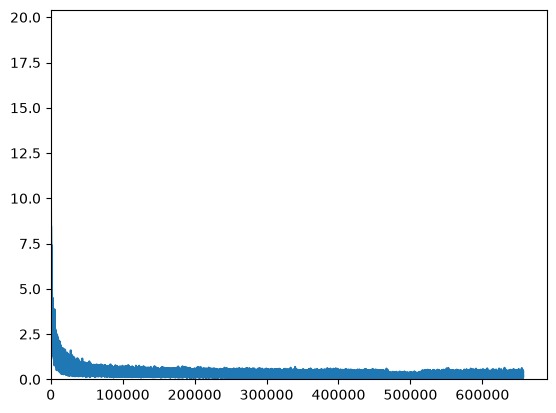

In [23]:
plt.plot(loss_vals)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()